In [1]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:90% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:12pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:12px;}
table {margin-left:0 !important; margin-right: auto;}
</style>
"""))

<font size="5" color="black">ch4. 머신러닝 모형 최적화</font>

# 1. 변수 선택과 차원 축소

## 1.1 변수 선택과 차원 축소

* 종속변수에 영향을 미치는 주요 변수를 선별하여 학습에 사용할 독립변수의 수를 줄이고 모델의 성능(score)을 향상시킴
* 과적합 방지 및 변수 간 다중공선성(높은 상관관계) 문제 완화
    * 다중공선성 발생 시 문제점 : 모델의 예측 성능이 우수하더라도 회귀계수 해석이 어려워지고, 주요 영향 변수 파악 및 p-value 기반 유의성 검정이 왜곡될 수 있음
* 부가적 이점 : 모델의 학습 및 계산 시간 단축
* 주성분분석(PCA), 상관분석, 분류 모델의 feature_importance_ 속성, 회귀 모델의 coef_ 속성
* SelectKBest : 평가 점수(score)가 가장 높은 상위 K개의 핵심 변수를 자동으로 선택

## 1.2 주성분분석 (PCA, Principal Component Analysis)

* 기존 변수들의 선형 결합을 통해 새로운 변수(주성분)를 생성하는 대표적인 변수 선택 및 차원 축소 기법
* 상관관계가 있는 변수들을 선형결합해서 **분산이 극대화된 상관관계가 없는 새로운 변수(주성분)들로 축약**하는 것
* 영상 인식, 통계 데이터 분석(주성분 탐색), 데이터 압축, 데이터 노이즈 제거 등
* 영상 처리에서의 활용 : 복수의 영상 데이터 중 대표 이미지를 추출할 때 주로 활용

In [2]:
import seaborn as sns
from sklearn.decomposition import PCA
iris = sns.load_dataset('iris')
iris_X, iris_y = iris.iloc[:,:-1], iris.iloc[:,-1]
iris_X.shape, iris_y.shape

((150, 4), (150,))

In [3]:
# 다중공전성이 있는 독립변수 4개 -> 다중공전성이 없는 새로운 독립변수 2개 (차원 축소)
pca = PCA(n_components=2) # n_components : 주성분 개수
pca.fit(iris_X)
iris_pca = pca.transform(iris_X)
iris_pca[:3]

array([[-2.68412563,  0.31939725],
       [-2.71414169, -0.17700123],
       [-2.88899057, -0.14494943]])

In [7]:
import pandas as pd
df = pd.DataFrame(iris_pca, columns=['pca1','pca2'])

In [8]:
df.corr()

,pca1,pca2
pca1,1.000000e+00,1.407550e-15
pca2,1.407550e-15,1.000000e+00


In [9]:
pd.concat([iris_X, df], axis=1)

,sepal_length,sepal_width,petal_length,petal_width,pca1,pca2
0,5.1,3.5,1.4,0.2,-2.684126,0.319397
1,4.9,3.0,1.4,0.2,-2.714142,-0.177001
2,4.7,3.2,1.3,0.2,-2.888991,-0.144949
3,4.6,3.1,1.5,0.2,-2.745343,-0.318299
4,5.0,3.6,1.4,0.2,-2.728717,0.326755
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,1.944110,0.187532
146,6.3,2.5,5.0,1.9,1.527167,-0.375317
147,6.5,3.0,5.2,2.0,1.764346,0.078859
148,6.2,3.4,5.4,2.3,1.900942,0.116628


In [10]:
# 설명 분산 : 각 주성분이 보존하는 원본 데이터의 절대적인 변동량 : 값이 클수록 더 중요한 주성분
pca.explained_variance_

array([4.22824171, 0.24267075])

In [11]:
# 각 주성분이 전체 데이터 정보량에서 차지하는 상대적인 설명 비율 (0~1)
pca.explained_variance_ratio_

array([0.92461872, 0.05306648])

In [14]:
# 2개의 주성분으로 전체 데이터의 97.768% 만큼 설명
import numpy as np
np.cumsum(pca.explained_variance_ratio_)

array([0.92461872, 0.97768521])

In [15]:
pca.components_

array([[ 0.36138659, -0.08452251,  0.85667061,  0.3582892 ],
       [ 0.65658877,  0.73016143, -0.17337266, -0.07548102]])

## 1.3 상관 관계 확인
- 타겟 변수와 상관 관계가 높은 독립 변수들만 선택하는 과정

In [17]:
redwine = pd.read_csv('data/winequality-red.csv', delimiter=';')
redwine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


- [cmap](https://jrc-park.tistory.com/155) <br>
http://seaborn.pydata.org/generated/seaborn.heatmap.html#seaborn.heatmap <br>
http://seaborn.pydata.org/examples/many_pairwise_correlations.html

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
plt.rcParams['figure.figsize'] = (15, 4)

In [19]:
corr = redwine.corr()

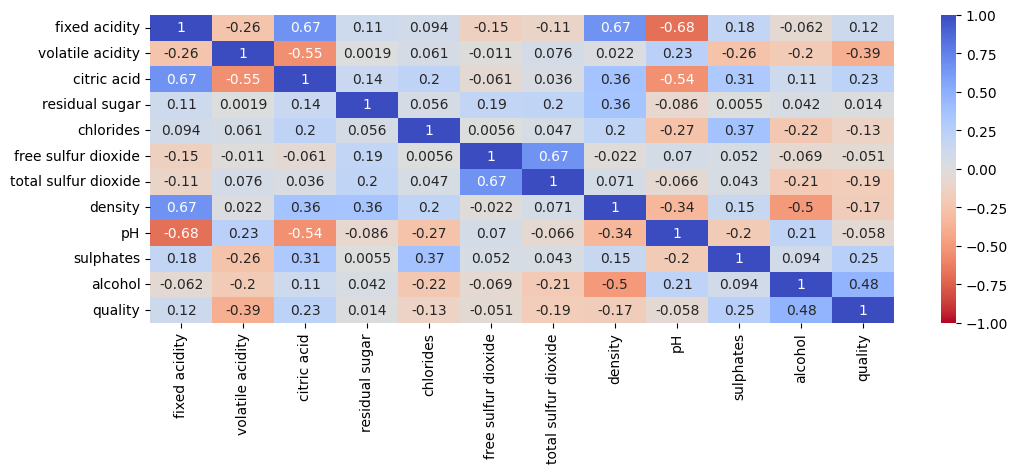

In [21]:
sns.heatmap(
    corr, # 표기할 데이터
    annot=True, # 수치 표기
    vmin=-1, # 수치 범위
    vmax=1,
    cmap="coolwarm_r"
)

plt.show()

In [22]:
mask = np.triu(np.ones_like(corr, dtype=bool))

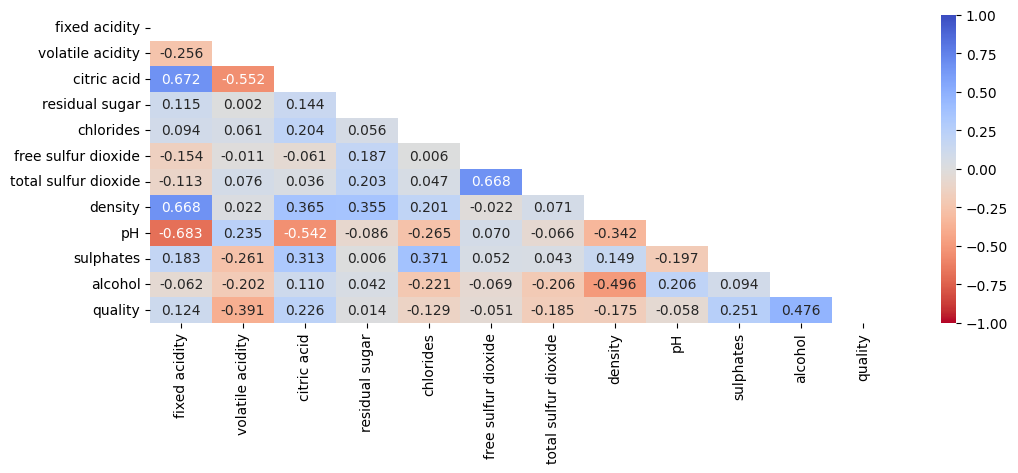

In [25]:
sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.3f',
    vmin=-1,
    vmax=1,
    cmap="coolwarm_r"
)
plt.show()

## 1.4 분류 모델 feature importance
* `feature_importances_` : 독립 변수가 종속 변수에 영향을 주는 정도를 저장
* DecisionTreeClassifier, RandomForestClassifier, GradientBoostingClassifier, XGBClassifier, LGBMClassifier, CatBoostClassifier
    - LogisticRegression, SVC, MLPClassifier, MultinomialNM 등은 feature_importances_을 지원하지 않음

In [28]:
X = redwine.iloc[:, :-1].to_numpy()
y = redwine.iloc[:, -1].values
from sklearn.model_selection import train_test_split
train_X, test_X, train_y, test_y = train_test_split(
    X, y,
    test_size=0.3,
    stratify=y
)
train_X.shape, train_y.shape, test_X.shape, test_y.shape, type(train_X)

((1119, 11), (1119,), (480, 11), (480,), numpy.ndarray)

In [29]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=10,
    random_state=10
)
rf_model.fit(train_X, train_y)

RandomForestClassifier(n_estimators=10, random_state=10)

In [32]:
features = pd.DataFrame(
    np.c_[redwine.columns[:-1],
    rf_model.feature_importances_],
    columns=['feature','importance']
)

In [33]:
features

,feature,importance
0,fixed acidity,0.068129
1,volatile acidity,0.098261
2,citric acid,0.085451
3,residual sugar,0.073955
4,chlorides,0.084156
5,free sulfur dioxide,0.069821
6,total sulfur dioxide,0.105074
7,density,0.082257
8,pH,0.075581
9,sulphates,0.11783


In [34]:
features.sort_values(by='importance', ascending=False, inplace=True)
features.set_index(drop=True, keys='feature')

,importance
feature,
alcohol,0.139487
sulphates,0.11783
total sulfur dioxide,0.105074
volatile acidity,0.098261
citric acid,0.085451
chlorides,0.084156
density,0.082257
pH,0.075581
residual sugar,0.073955


### 변수 중요도 시각화

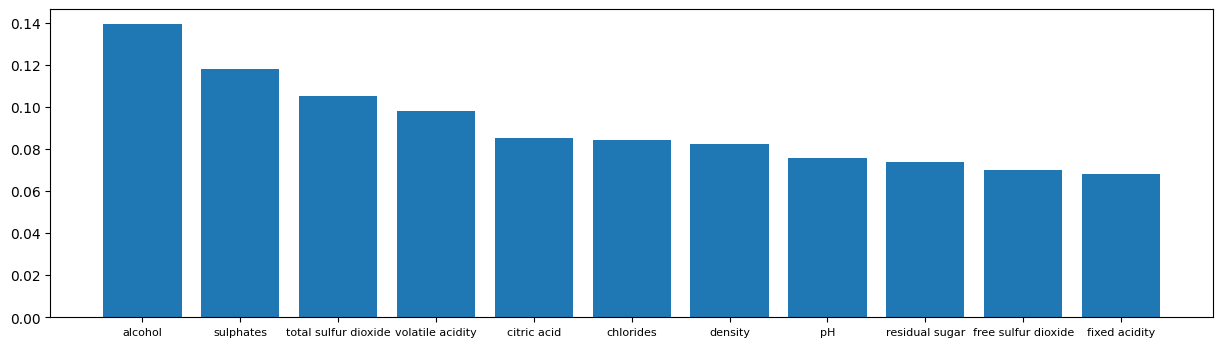

In [40]:
plt.bar(features.feature, features.importance)
plt.tick_params(axis='x', labelsize=8)
plt.show()

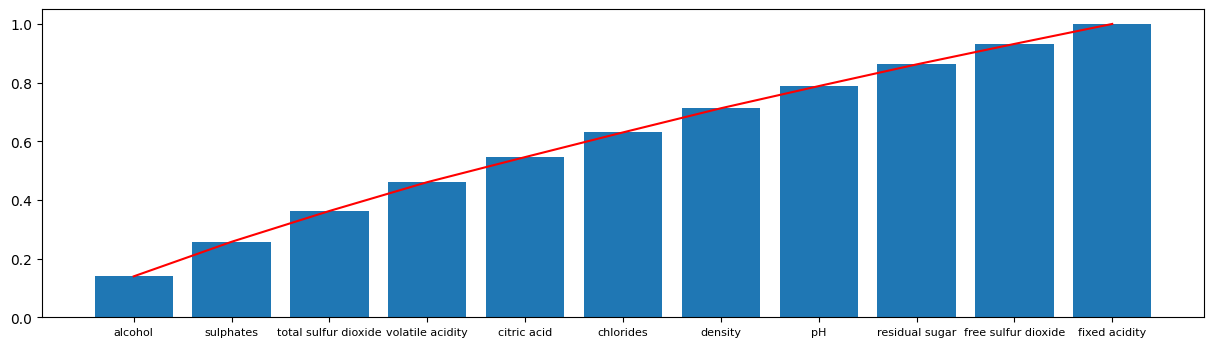

In [39]:
# 누적합을 이용한 시각화
y_stack = np.cumsum(features.importance)
plt.bar(features.feature, y_stack)
plt.plot(features.feature, y_stack, c='r')
plt.tick_params(axis='x', labelsize=8)
plt.show()

### RFE (Recursive Feature Elimination)
- 모델 기반 특성 중요도(Feature Importance) 평가를 바탕으로 하위 특성을 단계적으로 제거해 지정한 개수의 최적 변수 집합을 도출하는 후진 단계적 특성 선택 기법

In [42]:
from sklearn.feature_selection import RFE
rfe_model = RFE(
    rf_model,
    n_features_to_select=5
)
rfe_model.fit(train_X, train_y)

features_rfe = pd.DataFrame(
    np.c_[redwine.columns[:-1],
          rfe_model.get_support()],
    columns=['feature', 'selected']
)

features_rfe.sort_values(by='selected', ascending=False)

,feature,selected
1,volatile acidity,True
4,chlorides,True
6,total sulfur dioxide,True
9,sulphates,True
10,alcohol,True
0,fixed acidity,False
2,citric acid,False
3,residual sugar,False
5,free sulfur dioxide,False
7,density,False
